# Imports

In [ ]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes
import thresholds_functions as th
# Fit a Generalized Additive Model (GAM) to the interpolated progeria data
from pygam import LinearGAM, s


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import thresholds_functions as th
# Interpolate 1000 points between the progeria data points
from scipy.interpolate import interp1d
from ageing_packages.utils import SRFitter
from ageing_packages.utils.sr_utils import karin_params
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
usa = HMD(country = 'usa' , gender = 'both', data_type = 'period')
swe = HMD(country = 'swe' , gender = 'both', data_type = 'period')

n = 1e5
sim = utils.create_sr_simulation(n = n, parallel = True)
baseline_plotter = SR_plotting(sim)

# Creating progeria survival curves

## Loading Data and Preprocessing

In [4]:
progeria = pd.read_csv('saved_results/progeria.csv', header=None)
progeria_t = progeria[0].values; progeria_s = progeria[1].values
progeria_t = np.insert(progeria_t, 0, 0); progeria_s = np.insert(progeria_s, 0, 1)
# Add final point to ensure survival goes to 0
progeria_t = np.append(progeria_t, progeria_t[-1]+0.2)
progeria_s = np.append(progeria_s, 0)


# Create interpolation function
f = interp1d(progeria_t, progeria_s, kind='linear')
# Generate 1000 evenly spaced points between min and max t values
t_interp = np.linspace(min(progeria_t), max(progeria_t), 10000)
s_interp = f(t_interp)

# Create and fit the GAM
gam = LinearGAM(s(0, n_splines=20))
gam.fit(t_interp.reshape(-1, 1), s_interp)

# Generate predictions for plotting
t_pred = np.linspace(min(t_interp), max(t_interp), 200)
s_pred = gam.predict(t_pred)

random_samples = np.random.uniform(0, 1, 10000)

# Find corresponding t values by interpolating from s_pred to t_pred
# Since s_pred is decreasing (survival function), we need to reverse it for interpolation
t_samples = np.interp(random_samples, s_pred[::-1], t_pred[::-1])





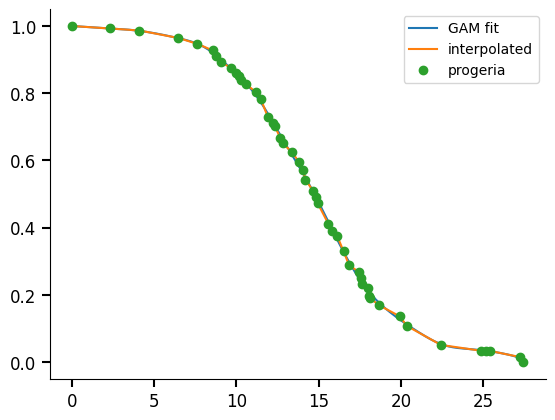

In [5]:
plt.plot(t_pred, s_pred, label = 'GAM fit')
plt.plot(t_interp, s_interp, label = 'interpolated')
plt.plot(progeria_t, progeria_s, label = 'progeria', marker = 'o', linewidth = 0)
plt.legend()
plt.show()

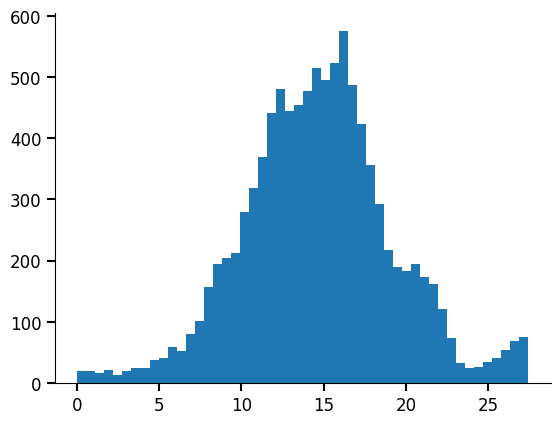

In [6]:
random_samples = np.random.uniform(0, 1, 10000)

# Find corresponding t values by interpolating from s_pred to t_pred
# Since s_pred is decreasing (survival function), we need to reverse it for interpolation
t_samples = np.interp(random_samples, s_pred[::-1], t_pred[::-1])

# Modify t_samples to make the last bin have the same height as the second-to-last bin
# First, create a histogram to identify the bins
hist_counts, bin_edges = np.histogram(t_samples, bins=50, density=True)

# Find the range of the last two bins
second_last_bin_start = bin_edges[-3]
second_last_bin_end = bin_edges[-2]
last_bin_start = bin_edges[-2]
last_bin_end = bin_edges[-1]

# Count samples in the second-to-last bin
second_last_count = np.sum((t_samples >= second_last_bin_start) & (t_samples < second_last_bin_end))

# Remove all samples from the last bin
t_samples_filtered = t_samples[t_samples < last_bin_start]

# Add the same number of samples to the last bin as in the second-to-last bin
last_bin_samples = np.random.uniform(last_bin_start, last_bin_end, second_last_count)
t_samples = np.concatenate([t_samples_filtered, last_bin_samples])

plt.hist(t_samples, bins=50)
plt.show()




## Making Survival Curves

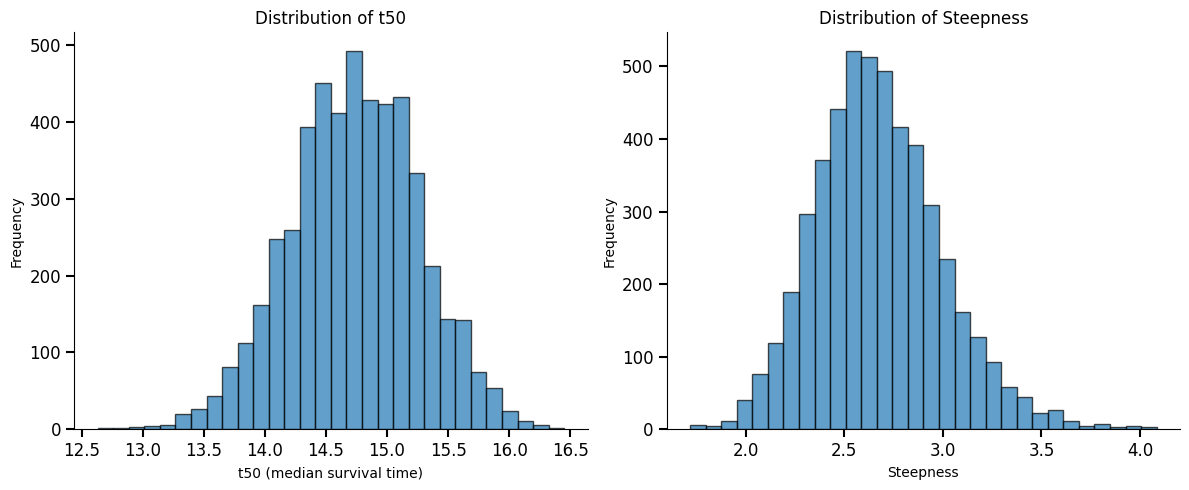

In [7]:
n = 104
n_simulations = 5000

# Initialize arrays to store results
t50_values = []
steepness_values = []

# Run simulation 1000 times
for i in range(n_simulations):
    deaths = np.random.choice(t_samples, size=n, replace=True)
    
    # Create KMF object and fit with death times (all observed)
    kmf = KaplanMeierFitter()
    kmf.fit(deaths, event_observed=np.ones(n))  # all deaths are observed
    
    # Extract survival times at specific percentiles
    t50 = kmf.percentile(0.5)  # median survival time
    t25 = kmf.percentile(0.25)  # 25th percentile survival time
    t75 = kmf.percentile(0.75)  # 75th percentile survival time
    
    # Calculate steepness
    steepness = t50 / (t25 - t75)
    
    # Store results
    t50_values.append(t50)
    steepness_values.append(steepness)

# Plot side by side histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Set font family to Arial
plt.rcParams['font.family'] = 'Arial'

# Plot t50 histogram
ax1.hist(t50_values, bins=30, alpha=0.7, edgecolor='black')
ax1.set_xlabel('t50 (median survival time)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of t50')

# Plot steepness histogram
ax2.hist(steepness_values, bins=30, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Steepness')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Steepness')

plt.tight_layout()
plt.show()


## Using risk set stuff

In [8]:
bins    = np.array([0,5,10,15,20,25,30])
n_start = np.array([204,156,103,43,11,2, 0])
d       = np.array([4,20,42,26,8,2])
c       = n_start[:-1] - d - n_start[1:]        # [44,33,18,6,1,0]

# Pre-compute interval samples for each bin to avoid repeated filtering
interval_samples_list = []
for i, (left, right) in enumerate(zip(bins[:-1], bins[1:])):
    interval_samples = t_samples[(t_samples >= left) & (t_samples < right)]
    interval_samples_list.append(interval_samples)

def progeria_bootstrap_median_steepness():
    # Pre-allocate arrays instead of using lists and appending
    total_events = np.sum(d) + np.sum(c)
    times = np.zeros(total_events)
    events = np.zeros(total_events, dtype=int)
    
    idx = 0
    for i, (left, right) in enumerate(zip(bins[:-1], bins[1:])):
        interval_samples = interval_samples_list[i]
        
        # Sample d[i] death times from the filtered samples
        if len(interval_samples) >= d[i]:
            death_times = np.random.choice(interval_samples, size=d[i], replace=False)
        else:
            # If not enough samples, sample with replacement
            death_times = np.random.choice(interval_samples, size=d[i], replace=True)
        
        # Add death times
        times[idx:idx+d[i]] = death_times
        events[idx:idx+d[i]] = 1
        idx += d[i]
        
        # Add censoring times
        if c[i] > 0:
            censor_times = np.random.uniform(left, right, c[i])
            times[idx:idx+c[i]] = censor_times
            events[idx:idx+c[i]] = 0
            idx += c[i]

    # Create DataFrame more efficiently
    df = pd.DataFrame({'time': times, 'event': events})

    kmf = KaplanMeierFitter()
    kmf.fit(df['time'], df['event'])

    t50 = kmf.percentile(0.5)
    t25 = kmf.percentile(0.25)
    t75 = kmf.percentile(0.75)

    steepness = t50 / (t25 - t75)
    
    return t50, steepness

t50, steepness = progeria_bootstrap_median_steepness()


In [9]:
t50_values = []
steepness_values = []
for i in range(10000):
    t50, steepness = progeria_bootstrap_median_steepness()
    t50_values.append(t50)
    steepness_values.append(steepness)


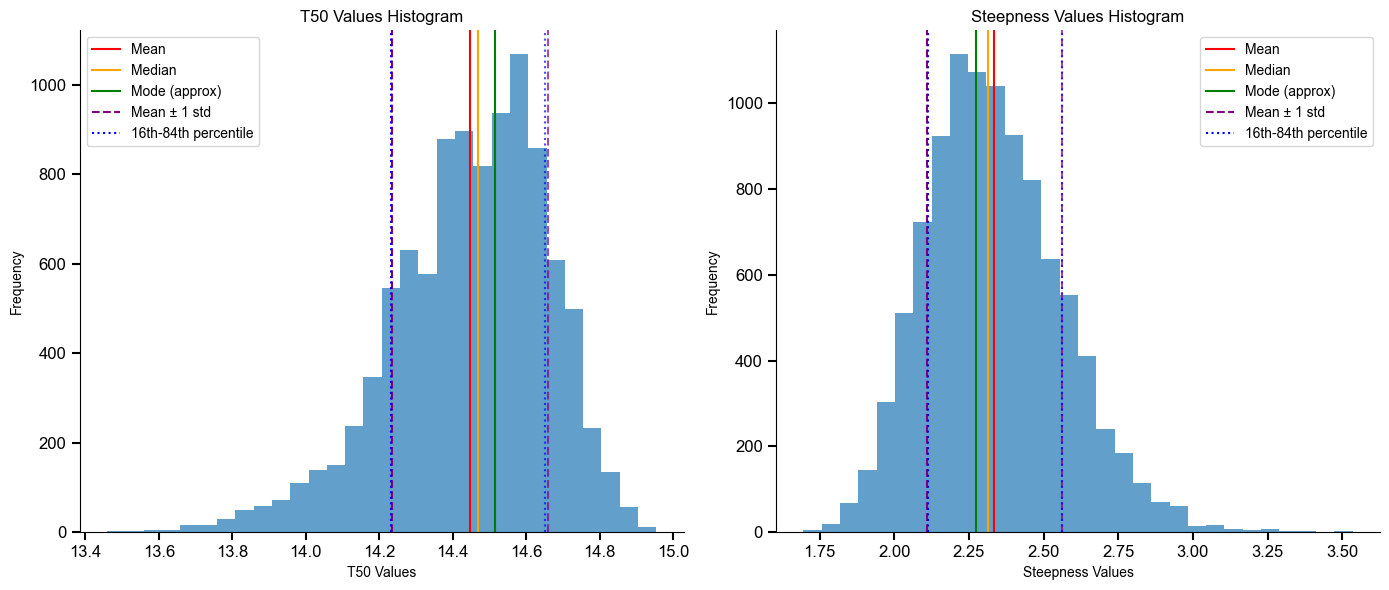

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
# T50 histogram
axs[0].hist(t50_values, bins=30, alpha=0.7)
axs[0].set_title('T50 Values Histogram', fontfamily='Arial')
axs[0].set_xlabel('T50 Values', fontfamily='Arial')
axs[0].set_ylabel('Frequency', fontfamily='Arial')

# Calculate statistics for T50
t50_mean = np.mean(t50_values)
t50_median = np.median(t50_values)
t50_mode = 3 * np.median(t50_values) - 2 * np.mean(t50_values)  # Empirical mode approximation
t50_std = np.std(t50_values)
t50_p16 = np.percentile(t50_values, 16)
t50_p84 = np.percentile(t50_values, 84)

# Add vertical lines for T50
axs[0].axvline(t50_mean, color='red', linestyle='-', label='Mean')
axs[0].axvline(t50_median, color='orange', linestyle='-', label='Median')
axs[0].axvline(t50_mode, color='green', linestyle='-', label='Mode (approx)')
axs[0].axvline(t50_mean - t50_std, color='purple', linestyle='--', label='Mean ± 1 std')
axs[0].axvline(t50_mean + t50_std, color='purple', linestyle='--', alpha=0.7)
axs[0].axvline(t50_p16, color='blue', linestyle=':', label='16th-84th percentile')
axs[0].axvline(t50_p84, color='blue', linestyle=':', alpha=0.7)
axs[0].legend(fontsize=10, prop={'family': 'Arial'})

# Steepness histogram
axs[1].hist(steepness_values, bins=30, alpha=0.7)
axs[1].set_title('Steepness Values Histogram', fontfamily='Arial')
axs[1].set_ylabel('Frequency', fontfamily='Arial')
axs[1].set_xlabel('Steepness Values', fontfamily='Arial')

# Calculate statistics for Steepness
steepness_mean = np.mean(steepness_values)
steepness_median = np.median(steepness_values)
steepness_mode = 3 * np.median(steepness_values) - 2 * np.mean(steepness_values)  # Empirical mode approximation
steepness_std = np.std(steepness_values)
steepness_p16 = np.percentile(steepness_values, 16)
steepness_p84 = np.percentile(steepness_values, 84)

# Add vertical lines for Steepness
axs[1].axvline(steepness_mean, color='red', linestyle='-', label='Mean')
axs[1].axvline(steepness_median, color='orange', linestyle='-', label='Median')
axs[1].axvline(steepness_mode, color='green', linestyle='-', label='Mode (approx)')
axs[1].axvline(steepness_mean - steepness_std, color='purple', linestyle='--', label='Mean ± 1 std')
axs[1].axvline(steepness_mean + steepness_std, color='purple', linestyle='--', alpha=0.7)
axs[1].axvline(steepness_p16, color='blue', linestyle=':', label='16th-84th percentile')
axs[1].axvline(steepness_p84, color='blue', linestyle=':', alpha=0.7)
axs[1].legend(fontsize=10, prop={'family': 'Arial'})

plt.tight_layout()
plt.show()

## Saving dadta

In [10]:
# Save progeria data to pickle file for reuse
import pickle

progeria_data = {
    'survival_curve': {
        't_pred': t_pred,
        's_pred': s_pred,
        't_half': np.interp(0.5, s_pred[::-1], t_pred[::-1])
    },
    'statistics': {
        't50_mean': t50_mean,
        't50_median': t50_median,
        't50_mode': t50_mode,
        't50_std': t50_std,
        't50_p16': t50_p16,
        't50_p84': t50_p84,
        'steepness_mean': steepness_mean,
        'steepness_median': steepness_median,
        'steepness_mode': steepness_mode,
        'steepness_std': steepness_std,
        'steepness_p16': steepness_p16,
        'steepness_p84': steepness_p84
    },
    'raw_data': {
        't50_values': t50_values,
        'steepness_values': steepness_values
    },
    'plotting_params': {
        'hgps_color': 'black'
    }
}

# Save to pickle file
progeria_pkl_path = th.saved_results_path + 'progeria_data.pkl'
with open(progeria_pkl_path, 'wb') as f:
    pickle.dump(progeria_data, f)

print(f"Progeria data saved to: {progeria_pkl_path}")


Progeria data saved to: /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/progeria_data.pkl


# loading up the data

In [11]:
# Load progeria data from pickle file
with open(th.saved_results_path + 'progeria_data.pkl', 'rb') as f:
    progeria_data = pickle.load(f)
    
progeria_survival = progeria_data['survival_curve']['s_pred']
progeria_times = progeria_data['survival_curve']['t_pred']

# Access loaded data as needed, e.g.:
# t_pred = progeria_data['survival_curve']['t_pred']
# s_pred = progeria_data['survival_curve']['s_pred']
# t50_mean = progeria_data['statistics']['t50_mean']


Running simulation for beta + epsilon with n=10000...

beta + epsilon:
  Cost: 0.076628
  Fitted parameters:
    beta = 6.530001 (0.12× Karin)
    epsilon = 16.401098 (0.32× Karin)
  All parameters (including non-fitted):
     eta = 0.492750 (1.00× Karin)
   * beta = 6.530001 (0.12× Karin)
     kappa = 0.500000 (1.00× Karin)
   * epsilon = 16.401098 (0.32× Karin)
     Xc = 17.000000 (1.00× Karin)
Running simulation for eta + Xc with n=10000...

eta + Xc:
  Cost: 0.106677
  Fitted parameters:
    eta = 1.895656 (3.85× Karin)
    Xc = 9.306240 (0.55× Karin)
  All parameters (including non-fitted):
   * eta = 1.895656 (3.85× Karin)
     beta = 54.750000 (1.00× Karin)
     kappa = 0.500000 (1.00× Karin)
     epsilon = 51.830000 (1.00× Karin)
   * Xc = 9.306240 (0.55× Karin)


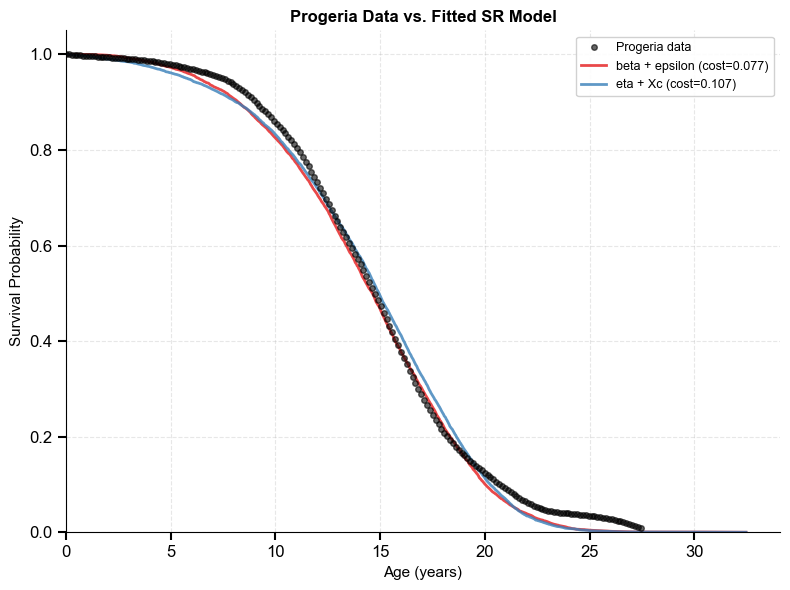

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Progeria Data vs. Fitted SR Model'}, xlabel='Age (years)', ylabel='Survival Probability'>)

In [88]:
import progeria_plotting
progeria_plotting.plot_fit(['beta + epsilon', 'eta + Xc'])

Running simulation for epsilon with n=10000...

epsilon:
  Cost: 5.222576
  Fitted parameters:
    epsilon = 159.418386 (3.08× Karin)
  All parameters (including non-fitted):
     eta = 0.492750 (1.00× Karin)
     beta = 54.750000 (1.00× Karin)
     kappa = 0.500000 (1.00× Karin)
   * epsilon = 159.418386 (3.08× Karin)
     Xc = 17.000000 (1.00× Karin)
Running simulation for Xc with n=10000...

Xc:
  Cost: 4.683024
  Fitted parameters:
    Xc = 6.997848 (0.41× Karin)
  All parameters (including non-fitted):
     eta = 0.492750 (1.00× Karin)
     beta = 54.750000 (1.00× Karin)
     kappa = 0.500000 (1.00× Karin)
     epsilon = 51.830000 (1.00× Karin)
   * Xc = 6.997848 (0.41× Karin)
Running simulation for beta with n=10000...

beta:
  Cost: 2.640156
  Fitted parameters:
    beta = 15.913052 (0.29× Karin)
  All parameters (including non-fitted):
     eta = 0.492750 (1.00× Karin)
   * beta = 15.913052 (0.29× Karin)
     kappa = 0.500000 (1.00× Karin)
     epsilon = 51.830000 (1.00× Karin)

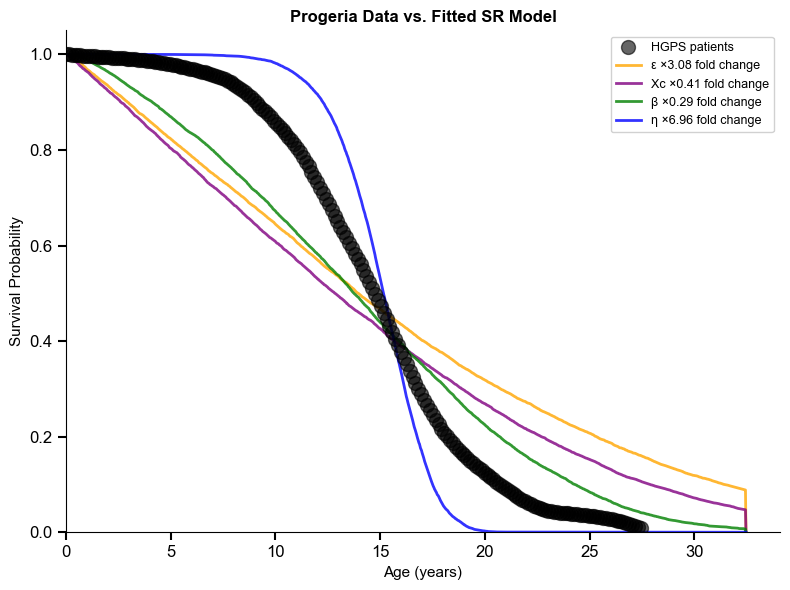

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Progeria Data vs. Fitted SR Model'}, xlabel='Age (years)', ylabel='Survival Probability'>)

In [146]:
import progeria_plotting
progeria_plotting.plot_fit(['epsilon', 'Xc', 'beta', 'eta'], colors = ['orange', 'purple', 'green', 'blue'])

Running simulation for beta + epsilon with n=10000...

beta + epsilon:
  Cost: 0.076628
  Fitted parameters:
    beta = 6.530001 (0.12× Karin)
    epsilon = 16.401098 (0.32× Karin)
  All parameters (including non-fitted):
     eta = 0.492750 (1.00× Karin)
   * beta = 6.530001 (0.12× Karin)
     kappa = 0.500000 (1.00× Karin)
   * epsilon = 16.401098 (0.32× Karin)
     Xc = 17.000000 (1.00× Karin)
Running simulation for eta + Xc with n=10000...

eta + Xc:
  Cost: 0.106677
  Fitted parameters:
    eta = 1.895656 (3.85× Karin)
    Xc = 9.306240 (0.55× Karin)
  All parameters (including non-fitted):
   * eta = 1.895656 (3.85× Karin)
     beta = 54.750000 (1.00× Karin)
     kappa = 0.500000 (1.00× Karin)
     epsilon = 51.830000 (1.00× Karin)
   * Xc = 9.306240 (0.55× Karin)
Running simulation for eta+beta with n=10000...

eta+beta:
  Cost: 0.114834
  Fitted parameters:
    eta = 1.182327 (2.40× Karin)
    beta = 23.922829 (0.44× Karin)
  All parameters (including non-fitted):
   * eta = 1.

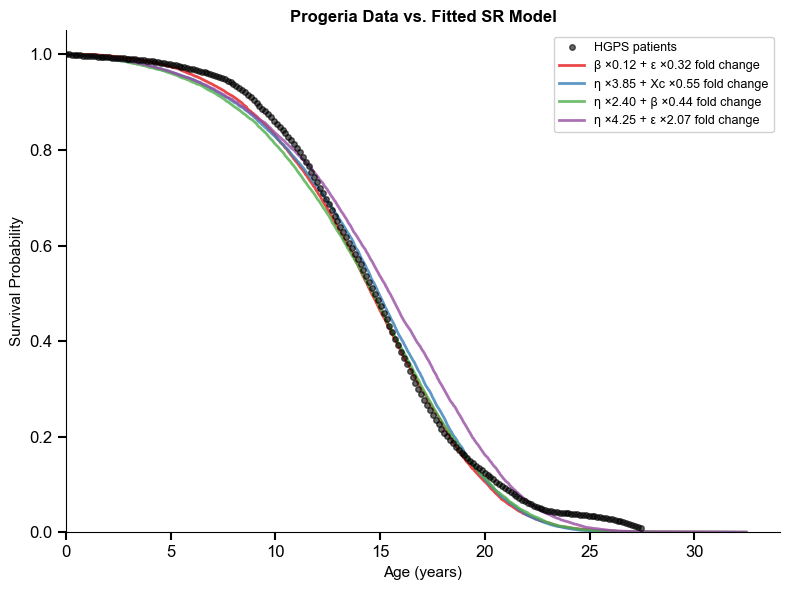

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Progeria Data vs. Fitted SR Model'}, xlabel='Age (years)', ylabel='Survival Probability'>)

In [ ]:
import progeria_plotting
progeria_plotting.plot_fit(['beta + Xc', 'beta + eta', 'beta + epsilon', 'eta + Xc', 'eta + epsilon', 'Xc + epsilon'])

# Werner

from paper, mean $\pm$ std =  $59 \pm 8.9$

In [ ]:
sweden_cohort = HMD(country = 'swe', gender = 'both', data_type = 'cohort')
sweden_period = HMD(country = 'swe', gender = 'both', data_type = 'period')

denmark_period = HMD(country = 'dan', gender = 'both', data_type = 'period')
denmark_cohort = HMD(country = 'dan', gender = 'both', data_type = 'cohort')

usa_period = HMD(country = 'usa', gender = 'both', data_type = 'period')

/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_77442/3484925460.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


(0.5, 1.5)

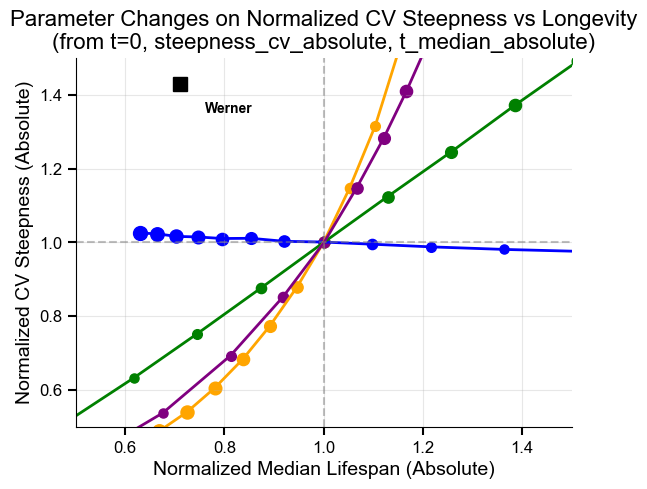

In [ ]:
werner_mean = 59; werner_std = 8.9; werner_steepness = 59 / 8.9

baseline_median = usa_period.calculate_median_lifespan(year = 2019)
baseline_steepness = usa_period.calculate_steepness(year = 2019, method = 'cv')

fig, ax = plt.subplots()

th.plot_steepness_longevity(pkl_file = 'param_variation_results_usa_2019.pkl', ax=ax, steepness_metric = 'steepness_cv_absolute')
ax.plot(werner_mean / baseline_median , werner_steepness / baseline_steepness, markersize = 10, marker = 's', color = 'black')
ax.legend().set_visible(False)
ax.text(werner_mean / baseline_median + 0.05, werner_steepness / baseline_steepness - 0.05, 
        'Werner', fontsize=10, fontweight='bold', ha='left', va='top', 
        fontfamily='Arial', color='black')

ax.set_xlim(0.5, 1.5)
ax.set_ylim(0.5, 1.5)